In [1]:
from util import *

import matplotlib.pyplot as plt
from astropy.io import fits

from astropy import coordinates
import astropy.units as u
from astroquery.simbad import Simbad
from astroquery.sdss import SDSS

import otter

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                  825 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-11-27T02:26:44' / Date FITS file was generated                  IRAF-TLM= '2024-11-27T02:26:44' / Time of last modification                     OBJECT  = '        '           / Name of the object observed                    NEXTEND =                    0 / Number of extensions                           CCDBIN1 =                    1 / Binning factor along axis 1                    CCDBIN2 =                    2 / Binning factor along axis 2                    FILENAME= 'TempImage2452.fits' / base fi

Text(0.02, 0.5, 'Normalized Flux')

/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)
/home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


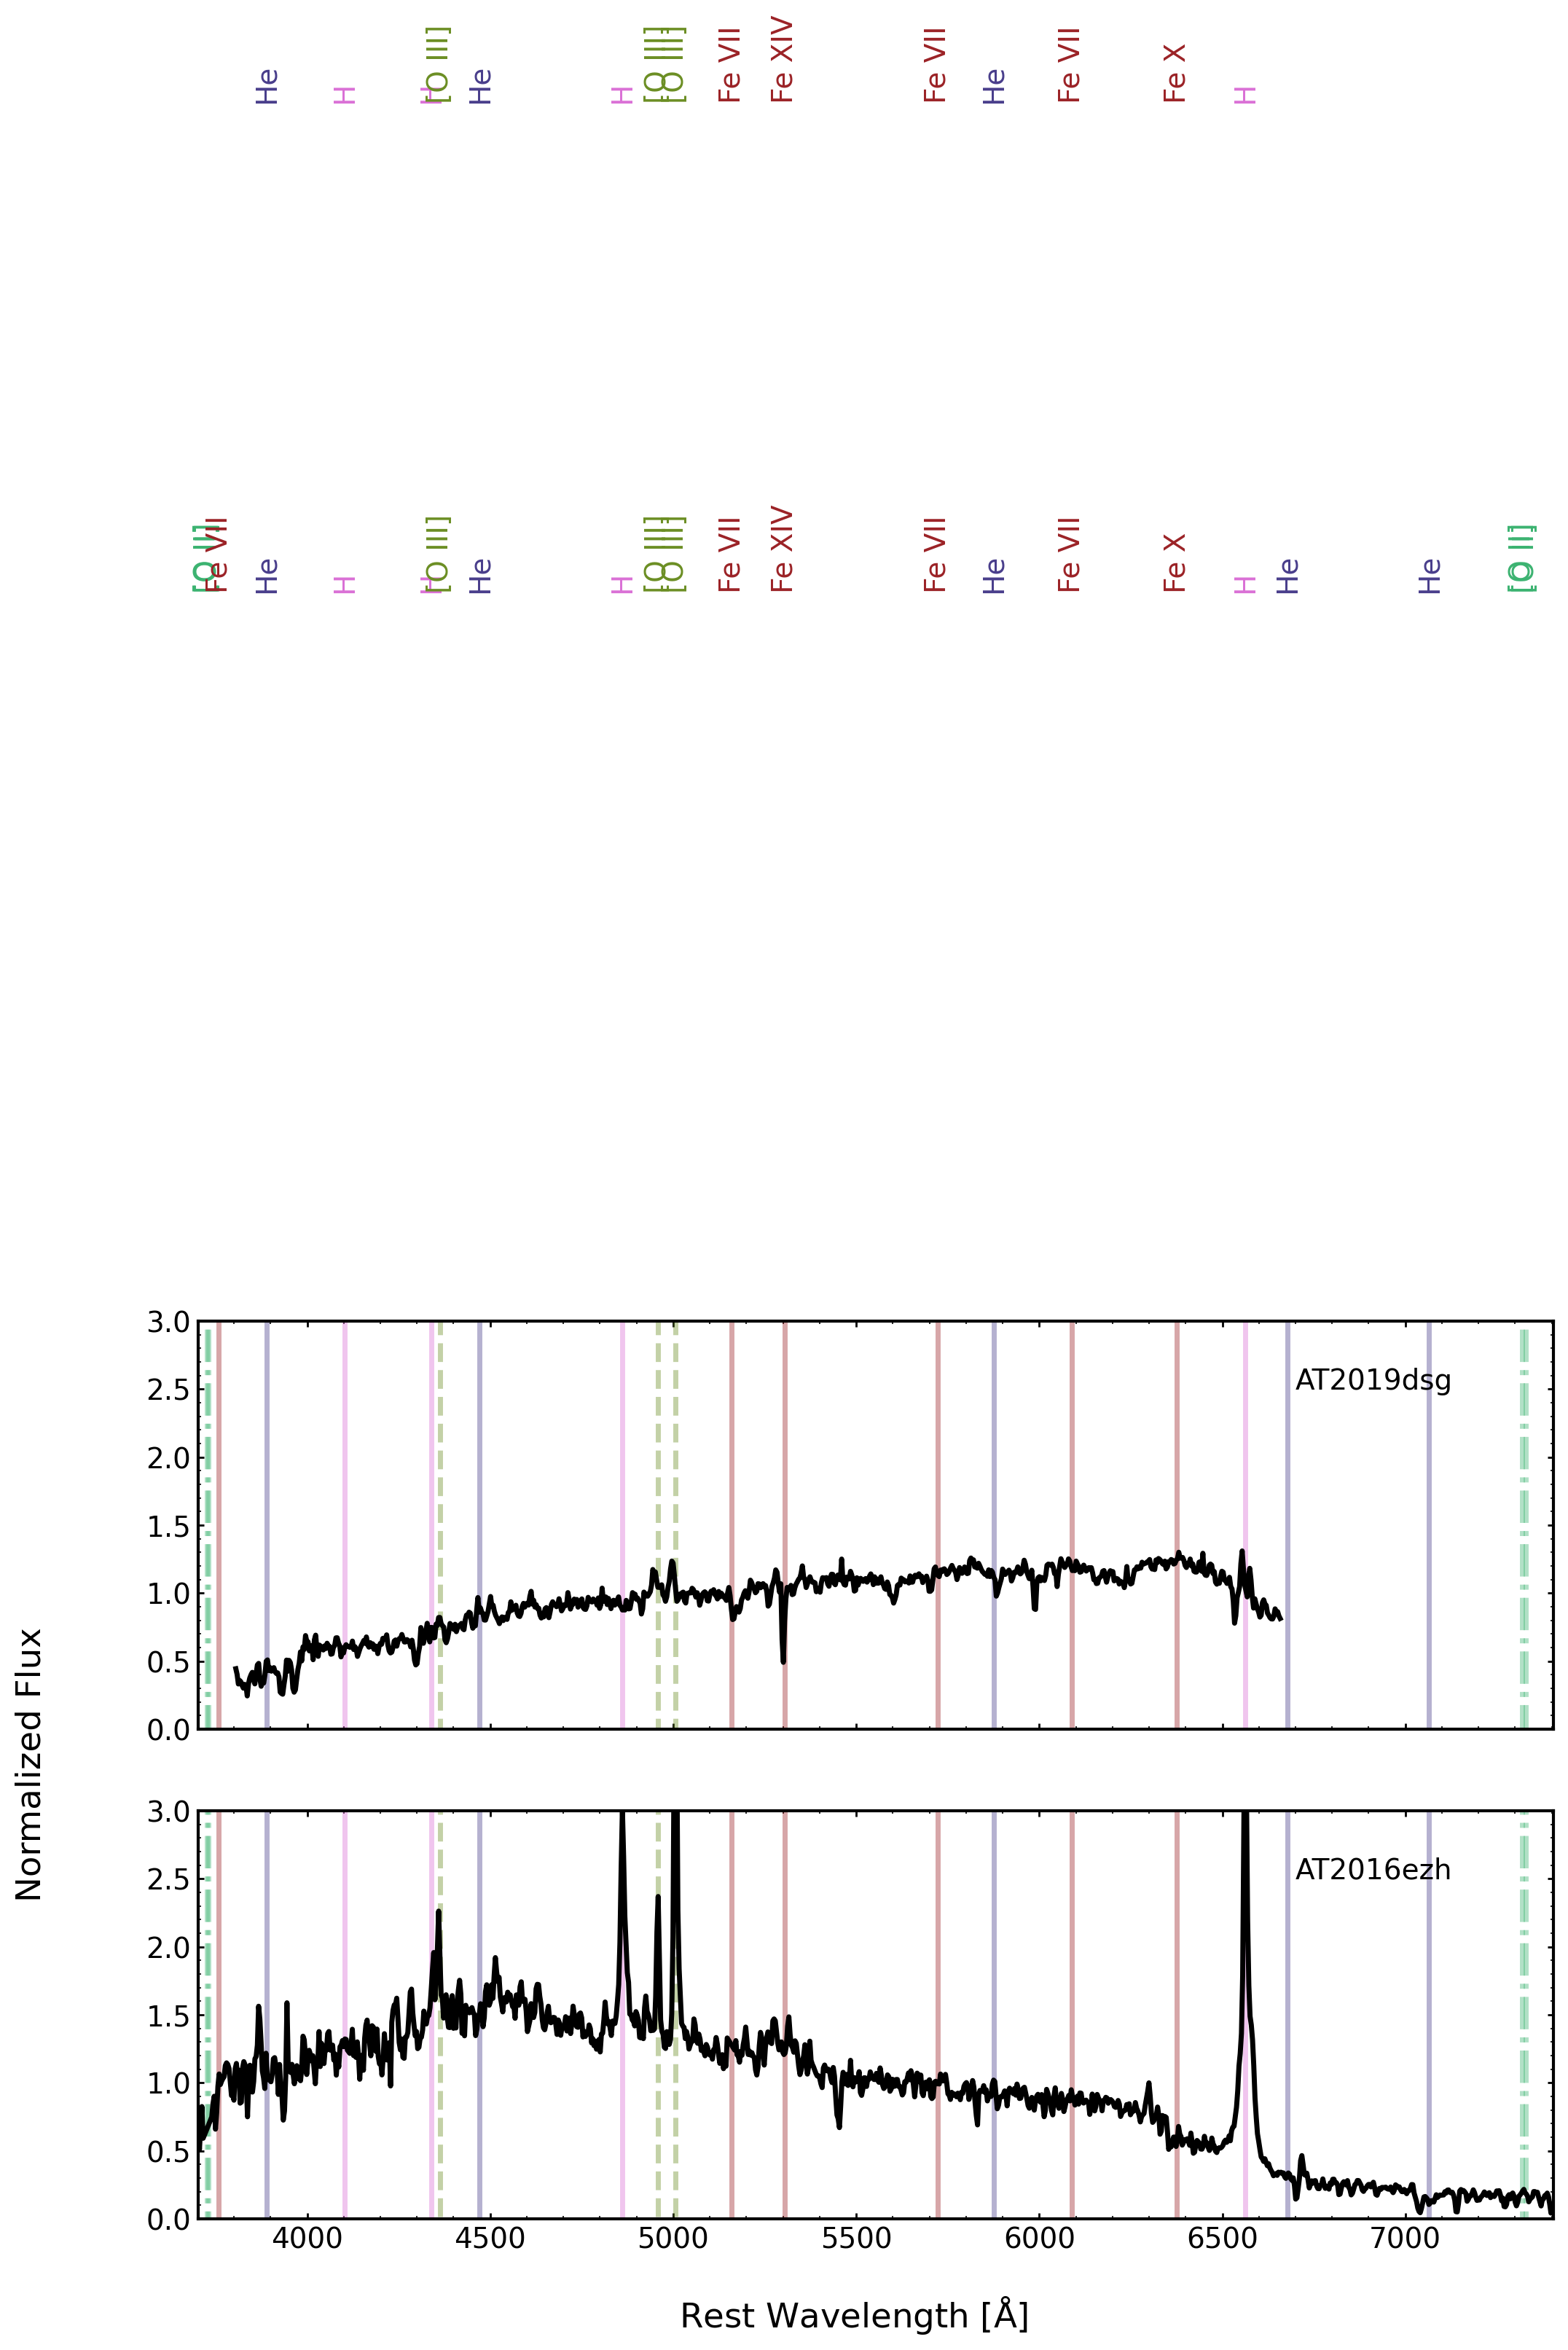

In [2]:
def read_and_plot(file, z, ax=None):
    spec = make_1d_spec(file)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,4))
    
    rest_wave = spec.wave/(1+z)

    ax.plot(rest_wave, spec.flux/np.nanmedian(spec.flux), color='k', zorder=100)

    linelist(
        ax=ax, 
        spacer=0, 
        start=12, 
        low=np.min(rest_wave), 
        high=np.max(rest_wave)
    )

    ax.set_xlim(np.min(rest_wave), np.max(rest_wave))
    ax.set_ylim(0,3)
    
    return ax

files = ["AT2019dsgHost_BokBC_20241106.fits", "AT2016ezh_BokBC_20241107.fits"]
zs = [0.0512, 0.0804]
labels = ["AT2019dsg", "AT2016ezh"]
fig, axs = plt.subplots(2,1,figsize=(12,8),sharex=True)

for file, z, label, ax in zip(files, zs, labels, axs):
    read_and_plot(file, z, ax=ax)
    ax.text(6700, 2.5, label)
    
fig.supxlabel(r"Rest Wavelength [$\AA$]")
fig.supylabel("Normalized Flux")

# Check SDSS for these objects

In [3]:
db = otter.Otter()
meta = db.get_meta(names=["AT2016ezh", "2019dsg"])

sdss_spec = []
for t in meta:
    pos = t.get_skycoord()
    
    xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)
    
    if xid is None:
        continue
    
    sp = SDSS.get_spectra(matches=xid)
    sdss_spec.append(sp)
    # im = SDSS.get_images(matches=xid, band='g')

In [4]:
data = sdss_spec[0][0][1]
lines = sdss_spec[0][0][3]

sdss_spec[0][0][0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TAI     =        4573438032.19 / 1st row - Number of seconds since Nov 17 1858  
RA      =            29.820312 / 1st row - Right ascension of telescope boresigh
DEC     =            0.010579  / 1st row - Declination of telescope boresight (d
EQUINOX =              2000.00 /                                                
RADECSYS= 'FK5     '           /                                                
TAIHMS  = '07:04:20.27'        / 1st row - TAI time (HH:MM:SS.SS) (TAI-UT = appr
TIMESYS = 'tai     '           / TAI, not UTC                                   
MJD     =                52933 / MJD of observation                             
MJDLIST = '52933   '        

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                 1100 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-12-03T00:52:55' / Date FITS file was generated                  IRAF-TLM= '2024-12-03T00:52:55' / Time of last modification                     OBJECT  = '        '           / Name of the object observed                    NEXTEND =                    0 / Number of extensions                           CCDBIN1 =                    1 / Binning factor along axis 1                    CCDBIN2 =                    2 / Binning factor along axis 2                    FILENAME= 'TempImage2452.fits' / base fi

Text(6700, 9, 'AT2016ezh')

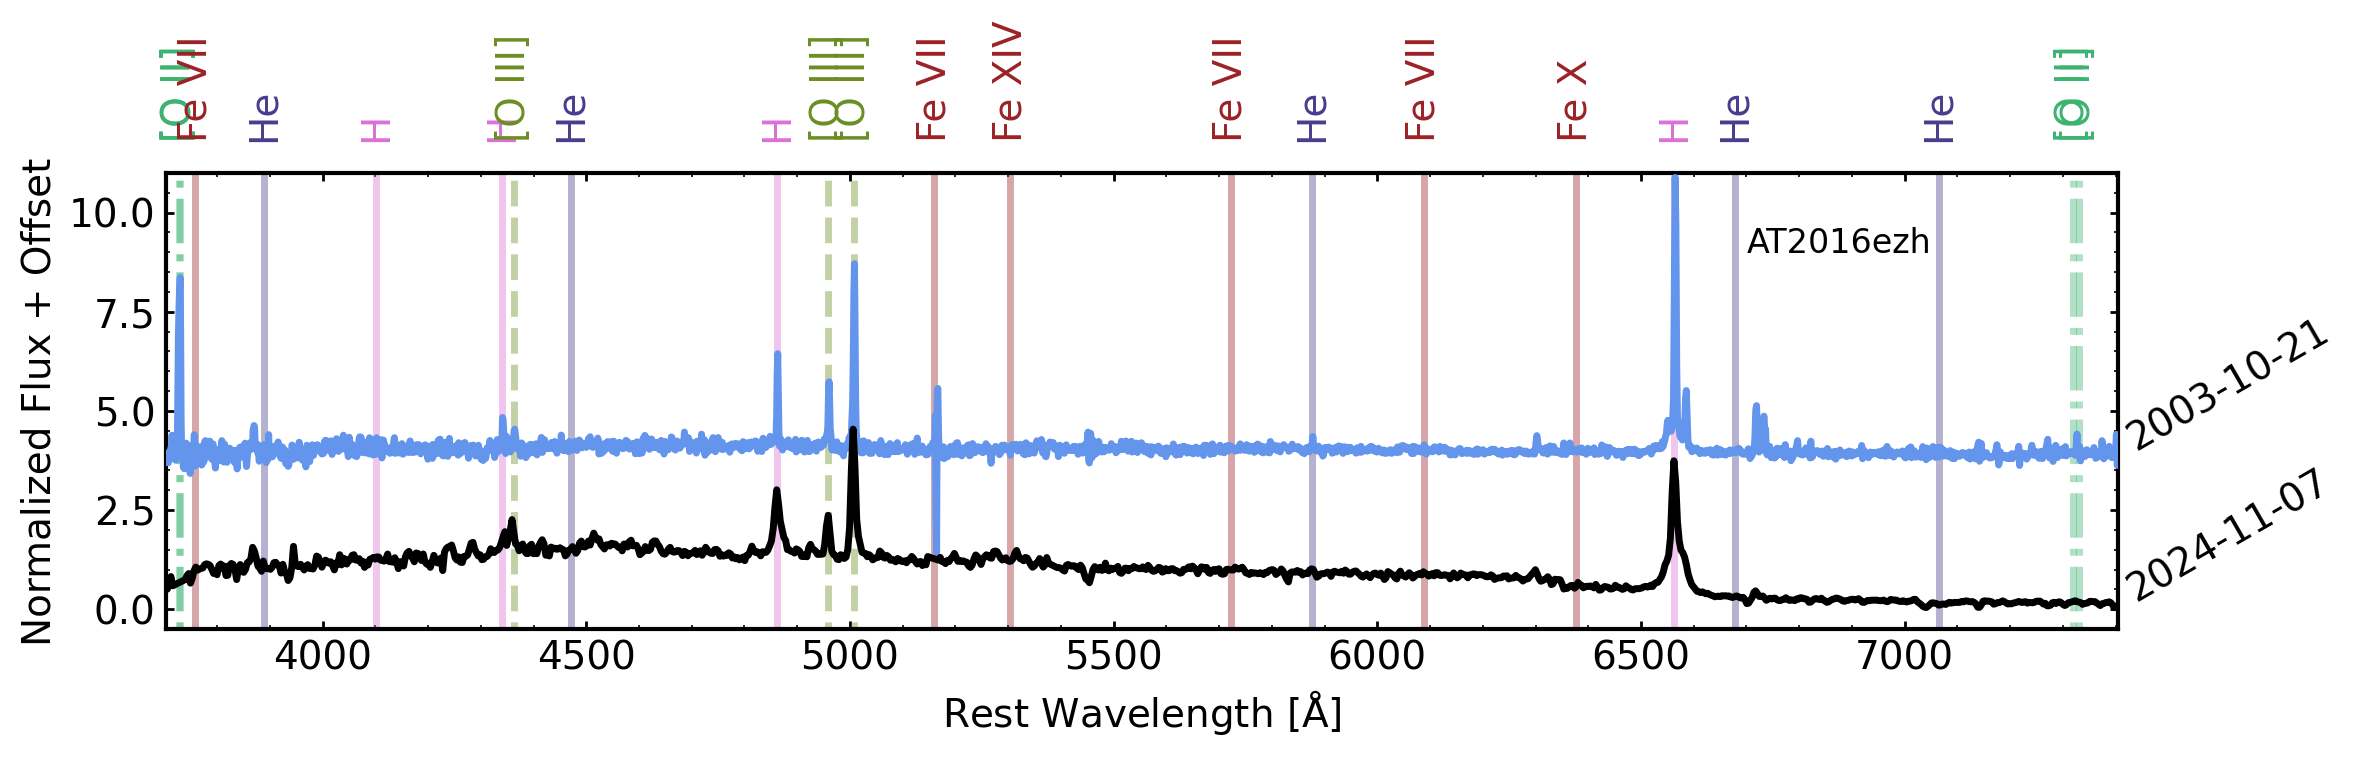

In [5]:
fig,ax = plt.subplots(figsize=(12,4))
from astropy.time import Time

z = float(db.get_meta(names="AT2016ezh")[0].get_redshift())

ax.plot(
    (10**data.data.loglam) / (1+z), 
    data.data.flux / np.nanmedian(data.data.flux) + 3, 
    color="cornflowerblue",
    zorder = 10
)

read_and_plot("AT2016ezh_BokBC_20241107.fits", z, ax=ax)

ax.set_ylabel("Normalized Flux + Offset")
ax.set_xlabel(r"Rest Wavelength [$\AA$]")

ax.set_ylim(-0.5, 11)

ax.text(7410, 3.8, f"{Time(52933, format='mjd').strftime('%Y-%m-%d')}", rotation=30, verticalalignment="bottom")
ax.text(7410, 0, "2024-11-07", rotation=30, verticalalignment="bottom")

ax.text(6700, 9, "AT2016ezh", fontsize=12)

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                 1100 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-12-03T00:52:55' / Date FITS file was generated                  IRAF-TLM= '2024-12-03T00:52:55' / Time of last modification                     OBJECT  = '        '           / Name of the object observed                    NEXTEND =                    0 / Number of extensions                           CCDBIN1 =                    1 / Binning factor along axis 1                    CCDBIN2 =                    2 / Binning factor along axis 2                    FILENAME= 'TempImage2452.fits' / base fi

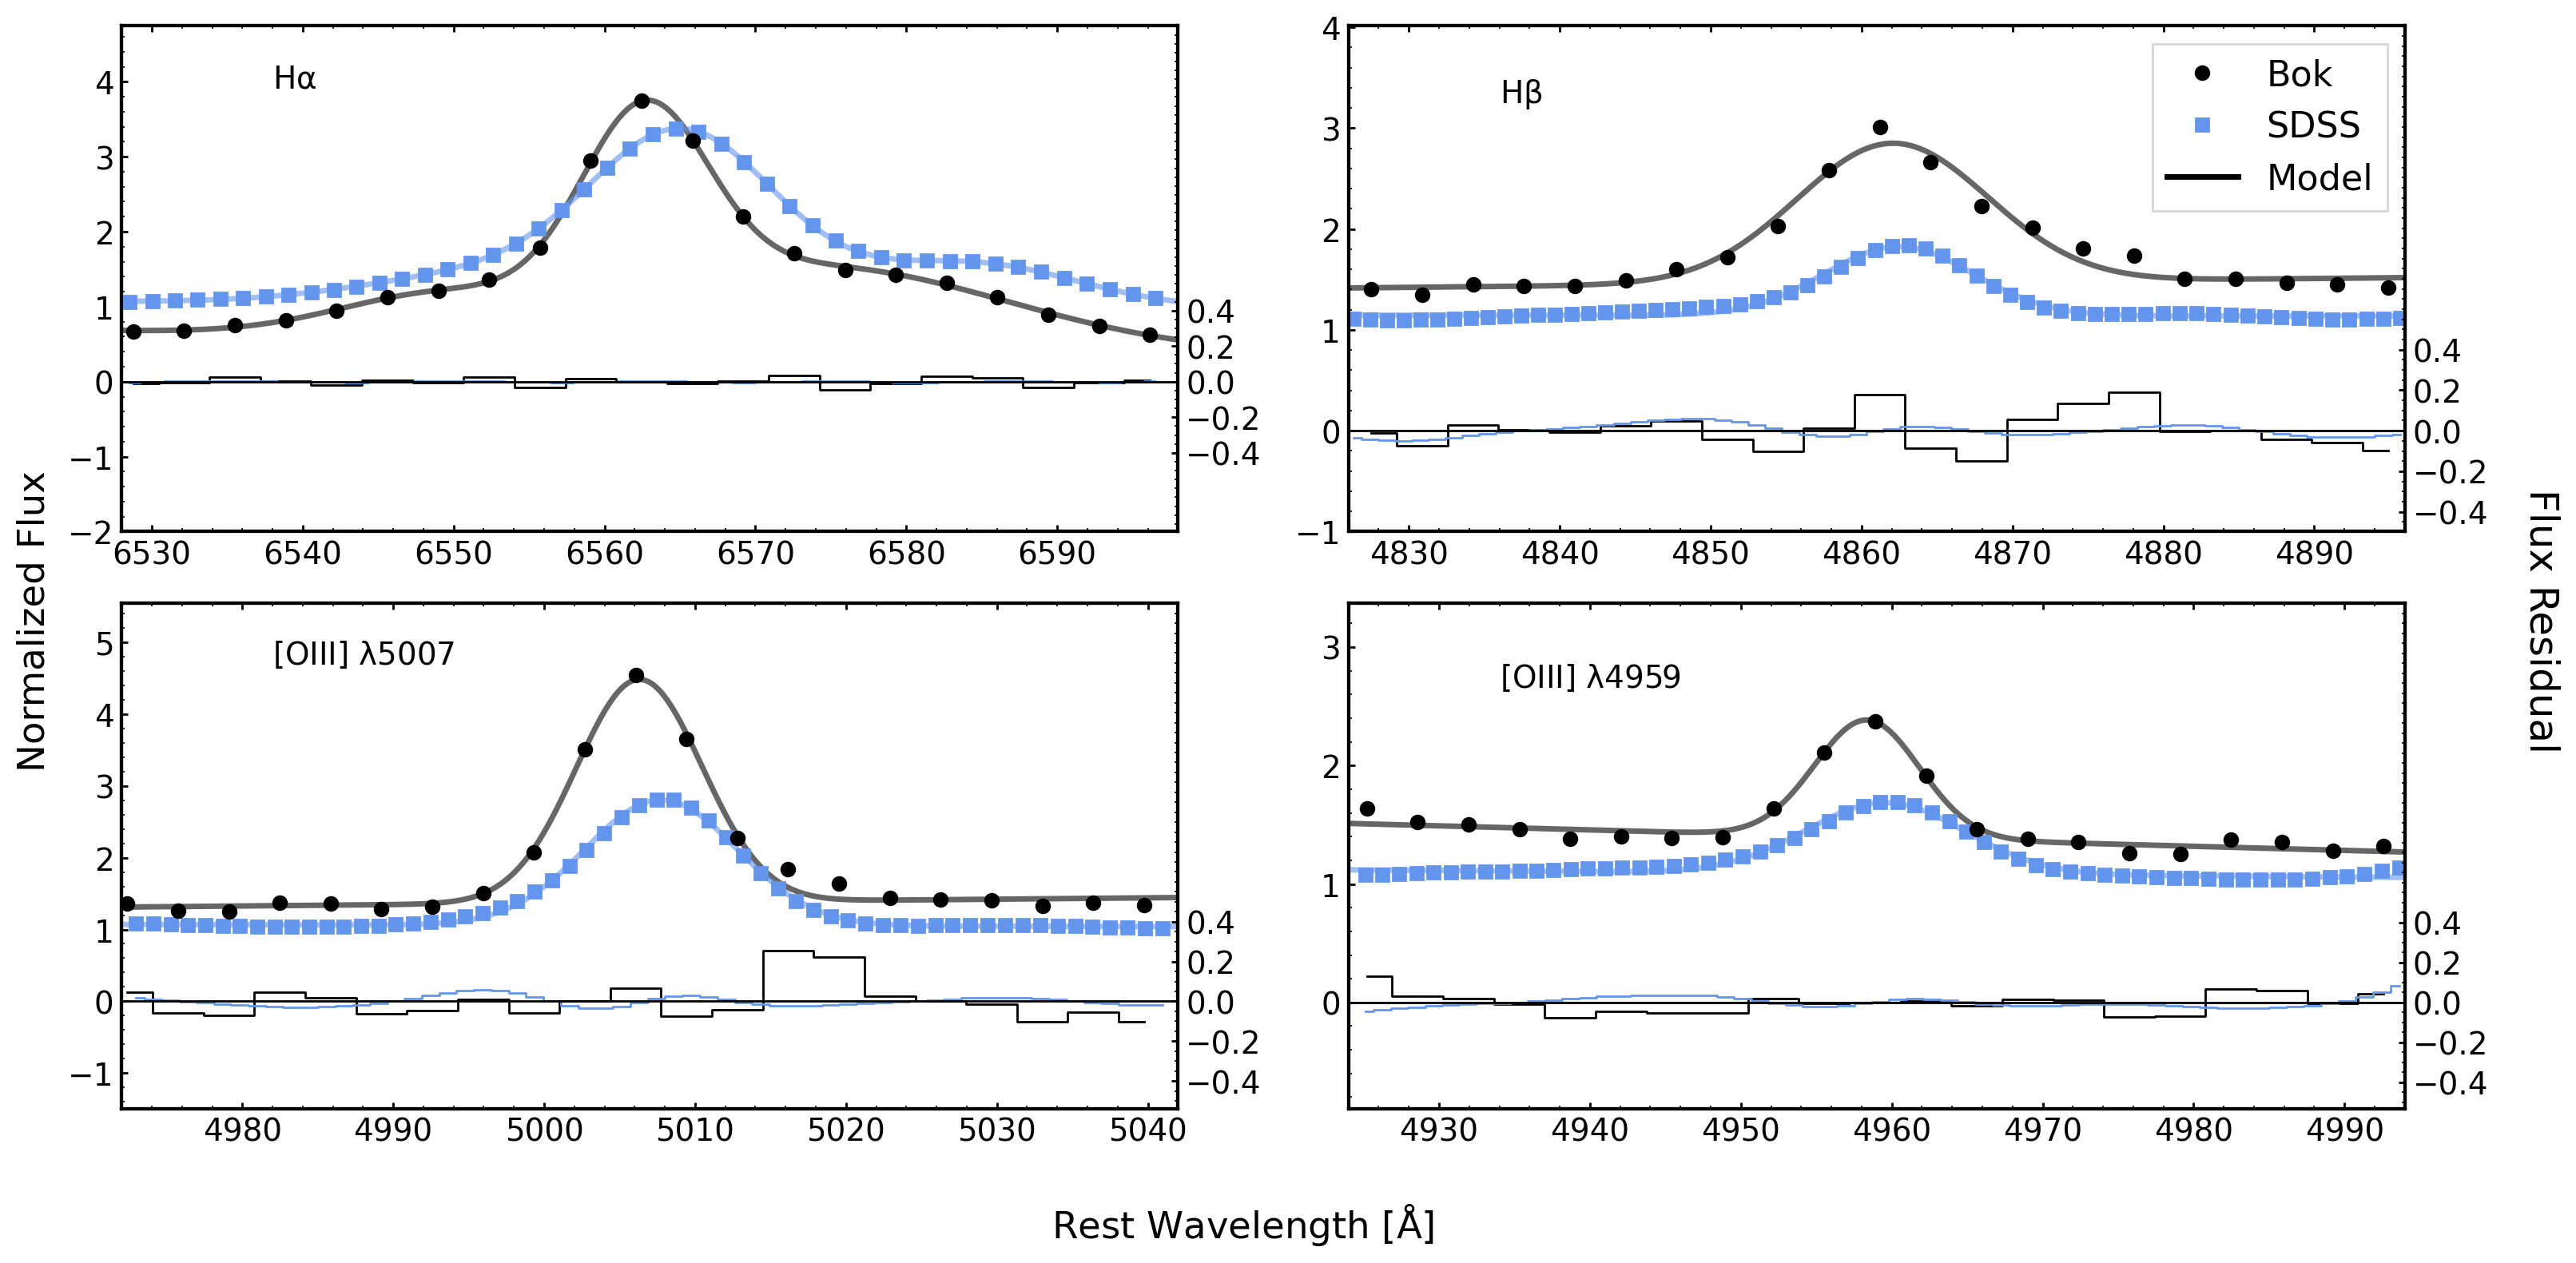

In [36]:
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.convolution import Gaussian1DKernel, convolve

# plot zoom ins of all of the lines of interest 4363, 4959
lines = {
    r"H$\alpha$":6563,
    r"H$\beta$": 4861,
    r"[OIII] $\lambda$5007":5007,
    r"[OIII] $\lambda$4959":4959,
    # r"[OIII] $\lambda$4363":4363,
}

bok = make_1d_spec(file)
sdss = sdss_spec[0][0][1].data

z = float(db.get_meta(names="AT2016ezh")[0].get_redshift())

fig, axs = plt.subplots(2,2, figsize=(16,8))

dw = 35
lw = 2

bok_res = (bok.wave[1] - bok.wave[0]) - 0.3
sdss_res = (10**sdss.loglam[1] - 10**sdss.loglam[0]) - 0.1

ymins = [-2, -1, -1.5, -0.9]

bok_color = "k"
sdss_color = "cornflowerblue"

def gauss(x, a, mu, sigma):
    return a*np.exp(-(x-mu)**2/(2.*sigma**2))

def single_gauss(x, *p):
    a, mu, sigma, m, b = p
    return b + m*x + gauss(x, a, mu, sigma)

def triple_gauss(x, *p):
    a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3, m, b = p
    return b+m*x + gauss(x, a1, mu1, sigma1) + gauss(x, a2, mu2, sigma2) + gauss(x, a3, mu3, sigma3)

def integrate_gauss_line(p, minx=3800, maxx=7800):
    return quad(gauss, minx, maxx, args=(*p,))

def print_quad_res(qres):
    print(rf"{qres[0]} $\pm$ {qres[1]}")
    
line_stds = dict(
    label = [],
    sdss = [],
    bok = []
)

bok_restwave = bok.wave / (1+z)
sdss_restwave = (10**sdss.loglam) / (1+z)

# downsample the SDSS data to emulate Bok
lam = min(bok_restwave) + (max(bok_restwave) - min(bok_restwave))/2
bok_dlam = 8.11
sdss_dlam = 6693/2000 # approximate from the SDSS page

bok_sigma = 8.11/2.355 # FWHM to sigma
sdss_sigma = sdss_dlam/2.355

std = np.sqrt(sdss_sigma**2 + bok_sigma**2)

print("std", std)
kernel = Gaussian1DKernel(stddev=std)
sdss_flux = convolve(sdss.flux, kernel)

sdss_normflux = sdss_flux / np.nanmedian(sdss_flux)
bok_normflux = bok.flux / np.median(bok.flux)

for ymin, ax, (label, wave) in zip(ymins, axs.flatten(), lines.items()):
    
    line_stds["label"].append(label)
    
    where_bok = np.where((bok_restwave > wave-dw) * (bok_restwave < wave+dw))[0]
    where_sdss = np.where((sdss_restwave > wave-dw) * (sdss_restwave < wave+dw))[0]
    
    ymax = max(max(sdss_normflux[where_sdss]), max(bok_normflux[where_bok]))+1
    
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(wave-dw, wave+dw)
    
    altax = ax.twinx()
    altax.set_ylim(2*ymin/ymax,2)
    altax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
    
    # initial guesses
    gauss_p0 = [
        4.,   # amplitude
        wave, # central wavelength
        3,    # standard deviation
    ]
    
    cont_p0 = [
        0.0001, # continuum slope
        1 # flux offset
    ]
    
    p0 = gauss_p0 + cont_p0
    line_model = single_gauss
    if wave == 6563:
        line_model = triple_gauss # for the NII lines on either side
        
        gauss_p1 = [
            0.1,   # amplitude
            6551, # central wavelength of NII
            1,    # standard deviation
        ]
        
        gauss_p2 = [
            3.,   # amplitude
            6583, # central wavelength of NII
            5,    # standard deviation
        ]
        
        p0 = gauss_p0 + gauss_p1 + gauss_p2 + cont_p0
    
    # Bok
    ax.plot(
        bok_restwave[where_bok],
        bok_normflux[where_bok],
        color=bok_color, 
        linestyle = "none",
        marker = "o",
        zorder=100,
        lw=lw,
    )
        
    coeff, var_matrix = curve_fit(
        line_model, 
        bok_restwave[where_bok], 
        bok_normflux[where_bok], 
        p0=p0
    )
    x = np.linspace(wave-dw, wave+dw, 1_000)
    ax.plot(
        x,
        line_model(x, *coeff),
        linestyle = "-",
        color = bok_color,
        alpha = 0.6
    )
    
    altax.step(
        bok_restwave[where_bok],
        bok_normflux[where_bok] - line_model(bok_restwave[where_bok], *coeff),
        lw = 1,
        color=bok_color,
        where = "mid"
    )
    
    line_stds["bok"].append(coeff[2])
    
    bok_line_flux = integrate_gauss_line(coeff[:3], minx=wave-5*dw, maxx=wave+5*dw)
    
    
    # SDSS    
    ax.plot(
        sdss_restwave[where_sdss], 
        sdss_normflux[where_sdss], 
        color=sdss_color,
        zorder = 10,
        linestyle = "none",
        marker = "s",
        lw = lw
    )
    
    coeff, var_matrix = curve_fit(
        line_model, 
        sdss_restwave[where_sdss], 
        sdss_normflux[where_sdss], 
        p0=p0
    )
    x = np.linspace(wave-dw, wave+dw, 1_000)
    ax.plot(
        x,
        line_model(x, *coeff),
        linestyle = "-",
        color = sdss_color,
        alpha = 0.6
    )
    
    altax.step(
        sdss_restwave[where_sdss],
        sdss_normflux[where_sdss] - line_model(sdss_restwave[where_sdss], *coeff),
        lw = 1,
        # width=sdss_res, 
        color=sdss_color,
        # bottom=0,
        where = "mid"
    )
        
    line_stds["sdss"].append(coeff[2])
    
    # also compute the line strengths of both the Bok and SDSS spectra 
    # by integrating the gaussian
    # SDSS is more complex cause we need to fit the original line profiles
    coeff, var_matrix = curve_fit(
        line_model, 
        sdss_restwave[where_sdss], 
        sdss.flux[where_sdss] / np.nanmedian(sdss.flux), 
        p0=p0
    )
    sdss_line_flux = integrate_gauss_line(coeff[:3], minx=wave-5*dw, maxx=wave+5*dw)
        
    ax.text(
        wave-dw + 10, 
        ymax - 0.5, 
        label,
        verticalalignment = "top"    
    )
    
    altax.axhline(0, color="k", lw=1)
    
    # ax.set_xlim(wave-dw, wave+dw)
    print()
    print(label)
    print("Bok:")
    print_quad_res(bok_line_flux)
    print("SDSS:")
    print_quad_res(sdss_line_flux)
        
fig.supylabel("Normalized Flux")
fig.supxlabel(r"Rest Wavelength [$\AA$]")
fig.text(1, 0.5, 'Flux Residual', va='center', rotation=-90, fontsize=18)

from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color="k", linestyle="none", marker="o"),
    Line2D([0], [0], color="cornflowerblue", linestyle="none", marker="s"),
    Line2D([0], [0], color="k", linestyle="-"),
    #Line2D([0], [0], color="k", linestyle="--")
]
line_labels = ["Bok", "SDSS", "Model"]
axs.flatten()[1].legend(
    custom_lines, 
    line_labels, 
    loc="upper right", 
    fontsize=16,
    frameon=True,
    fancybox=False,
    ncols=1
)

In [22]:
line_df = pd.DataFrame(line_stds)
line_df["delta_lambda_factor"] = line_df.bok/line_df.sdss

line_df

,label,sdss,bok,delta_lambda_factor
0,H$\alpha$,6.118689,4.176375,0.682560
1,H$\beta$,4.885408,6.335998,1.296923
2,[OIII] $\lambda$5007,5.001952,4.169127,0.833500
3,[OIII] $\lambda$4959,5.213283,3.475533,0.666669


In [12]:
print(line_df.to_markdown())

|    | label                |    sdss |     bok |   delta_lambda_factor |
|---:|:---------------------|--------:|--------:|----------------------:|
|  0 | H$\alpha$            | 4.5994  | 4.17638 |              0.908026 |
|  1 | H$\beta$             | 3.4174  | 6.336   |              1.85404  |
|  2 | [OIII] $\lambda$5007 | 3.71987 | 4.16913 |              1.12077  |
|  3 | [OIII] $\lambda$4959 | 3.92513 | 3.47553 |              0.885457 |
